## 📦 1. 环境准备与数据加载

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 通过 rc 参数设置中文字体
sns.set_theme(
    style="white",
    font_scale=1.1,
    rc={
        "font.sans-serif": ["Microsoft YaHei"],
        "font.family": "sans-serif",
        "axes.unicode_minus": False
    }
)

# 加载 car_crashes 数据集
df = sns.load_dataset("car_crashes")
print(df.head())
print(f"\n数据规模：{df.shape}")

   total  speeding  alcohol  not_distracted  no_previous  ins_premium  \
0   18.8     7.332    5.640          18.048       15.040       784.55   
1   18.1     7.421    4.525          16.290       17.014      1053.48   
2   18.6     6.510    5.208          15.624       17.856       899.47   
3   22.4     4.032    5.824          21.056       21.280       827.34   
4   12.0     4.200    3.360          10.920       10.680       878.41   

   ins_losses abbrev  
0      145.08     AL  
1      133.93     AK  
2      110.35     AZ  
3      142.39     AR  
4      165.63     CA  

数据规模：(51, 8)


## 🔥 2. 基础热力图：相关性矩阵

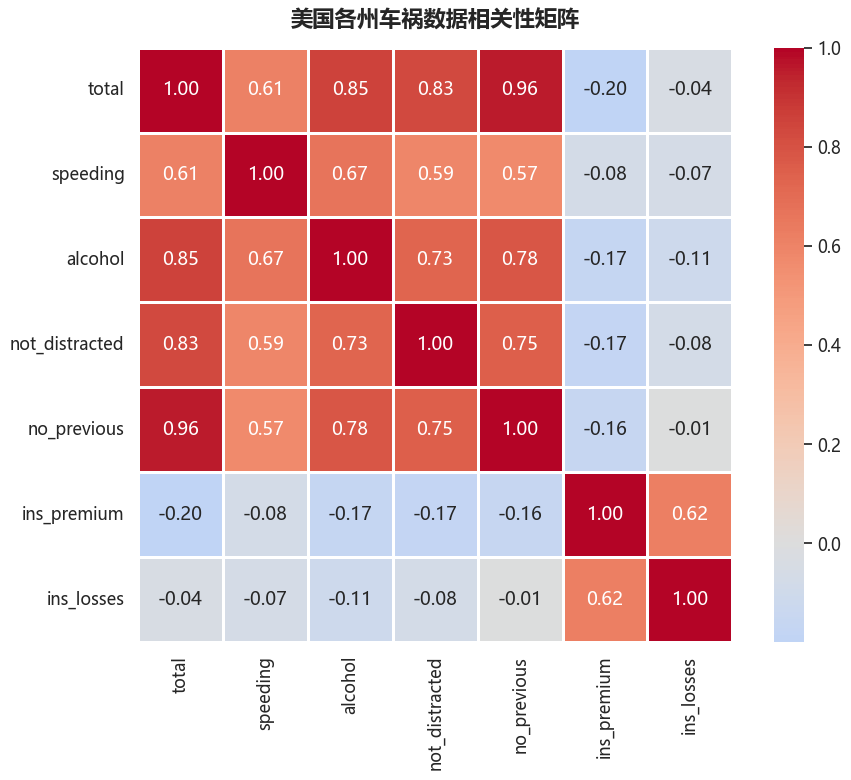

In [2]:
fig, ax = plt.subplots(figsize=(10, 8))

# 计算相关系数矩阵
corr = df.corr(numeric_only=True)

# Seaborn 一行代码画出热力图
sns.heatmap(
    corr,
    annot=True,         # 显示数值标签
    fmt=".2f",          # 保留 2 位小数
    cmap="coolwarm",    # 红蓝渐变色板
    center=0,           # 中心值为 0
    square=True,        # 方块为正方形
    linewidths=1,       # 网格线宽度
    ax=ax
)

ax.set_title("美国各州车祸数据相关性矩阵", fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

## 🎨 3. 高级定制：自定义色板 + 网格优化

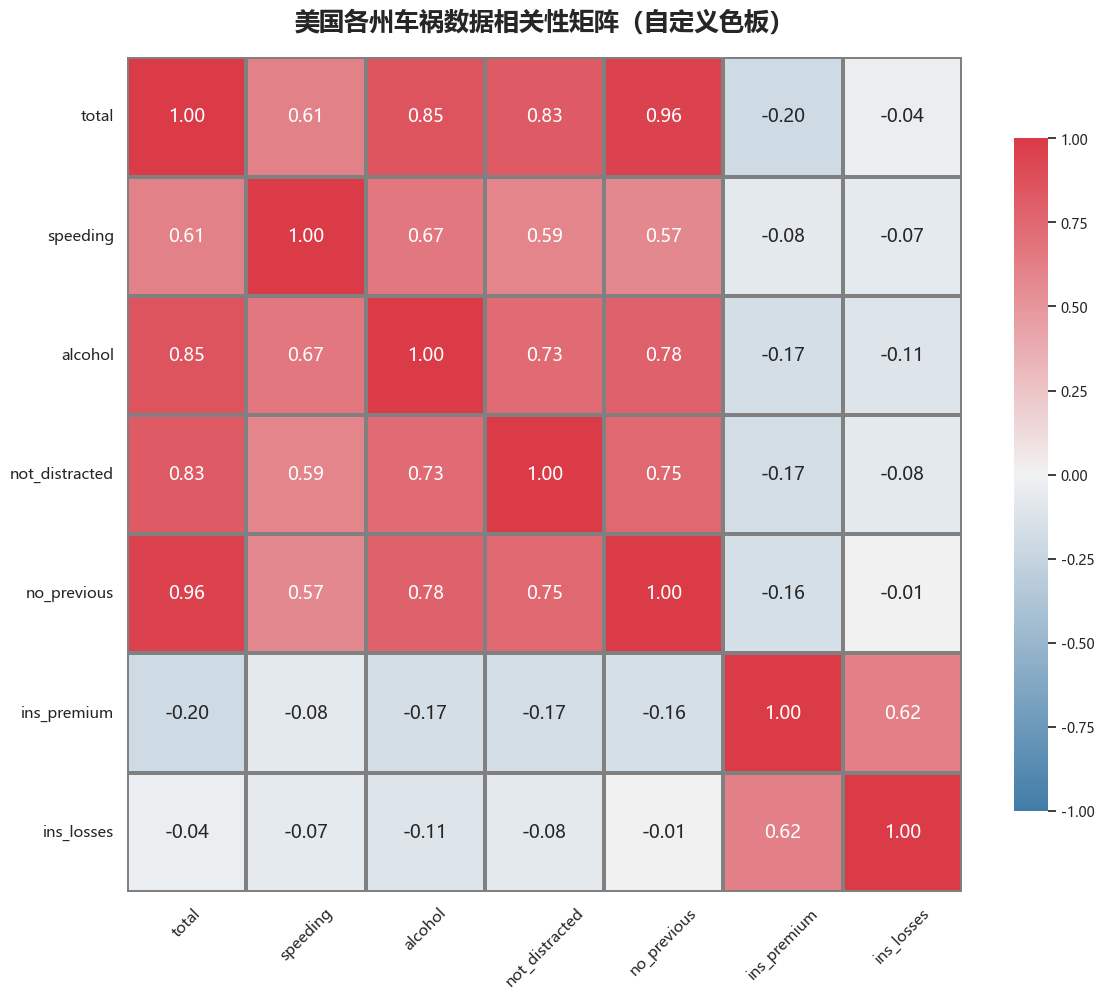

In [3]:
fig, ax = plt.subplots(figsize=(12, 10))

corr = df.corr(numeric_only=True)

# 自定义渐变色板（从深蓝到深红）
custom_cmap = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    square=True,
    linewidths=1.5,
    linecolor="gray",
    cbar_kws={"shrink": 0.8},
    ax=ax,
    vmin=-1, vmax=1
)

ax.set_title("美国各州车祸数据相关性矩阵（自定义色板）", fontsize=18, fontweight="bold", pad=20)
ax.tick_params(axis="x", rotation=45, labelsize=11)
ax.tick_params(axis="y", rotation=0, labelsize=11)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("correlation_heatmap_advanced.png", dpi=300, bbox_inches="tight")
plt.show()

## 🎭 4. 高级玩法：蒙版上三角 + 隐藏对角线

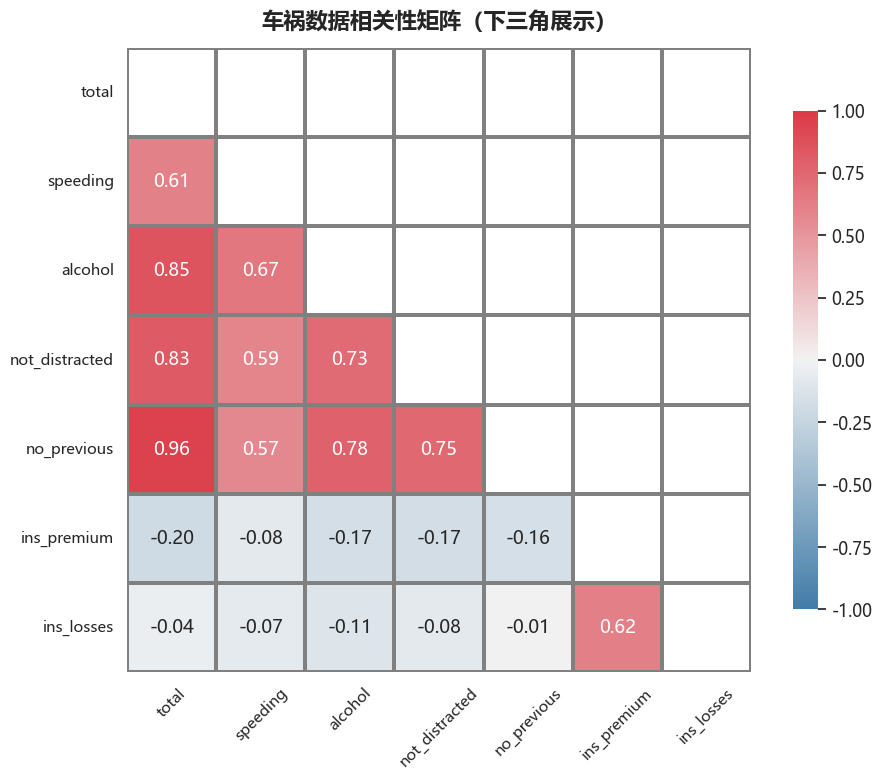

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df.corr(numeric_only=True)

# 创建蒙版：隐藏上三角和对角线
mask = np.triu(np.ones_like(corr, dtype=bool))

custom_cmap = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    square=True,
    linewidths=1.5,
    linecolor="gray",
    cbar_kws={"shrink": 0.8},
    ax=ax,
    vmin=-1, vmax=1
)

ax.set_title("车祸数据相关性矩阵（下三角展示）", fontsize=16, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=11)
ax.tick_params(axis="y", rotation=0, labelsize=11)

plt.tight_layout()
plt.savefig("correlation_lower_triangle.png", dpi=300, bbox_inches="tight")
plt.show()

## 🔍 5. 聚焦分析：关键变量相关性

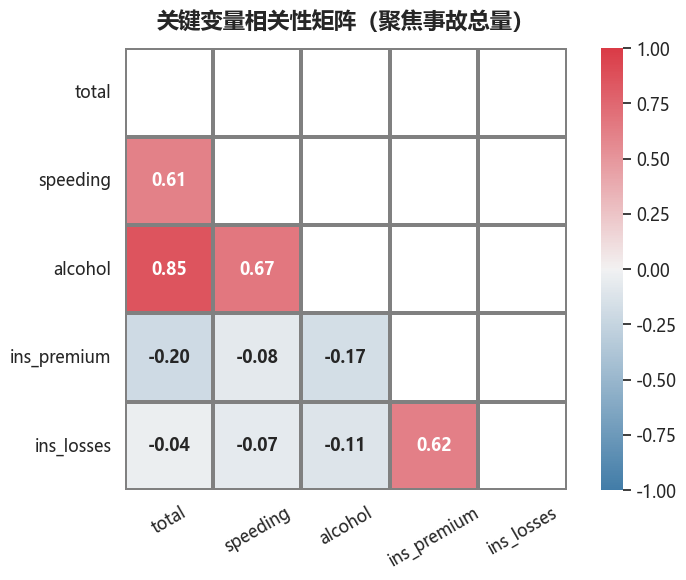

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

# 只选择关键变量
key_vars = ["total", "speeding", "alcohol", "ins_premium", "ins_losses"]
corr_key = df[key_vars].corr()

custom_cmap = sns.diverging_palette(240, 10, as_cmap=True)
mask = np.triu(np.ones_like(corr_key, dtype=bool))

sns.heatmap(
    corr_key,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    square=True,
    linewidths=1.5,
    linecolor="gray",
    ax=ax,
    vmin=-1, vmax=1,
    annot_kws={"fontsize": 12, "fontweight": "bold"}
)

ax.set_title("关键变量相关性矩阵（聚焦事故总量）", fontsize=16, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=30, labelsize=12)
ax.tick_params(axis="y", rotation=0, labelsize=12)

plt.tight_layout()
plt.savefig("key_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 💾 6. 完整代码模板

✅ 图表已保存为 'correlation_heatmap.png'


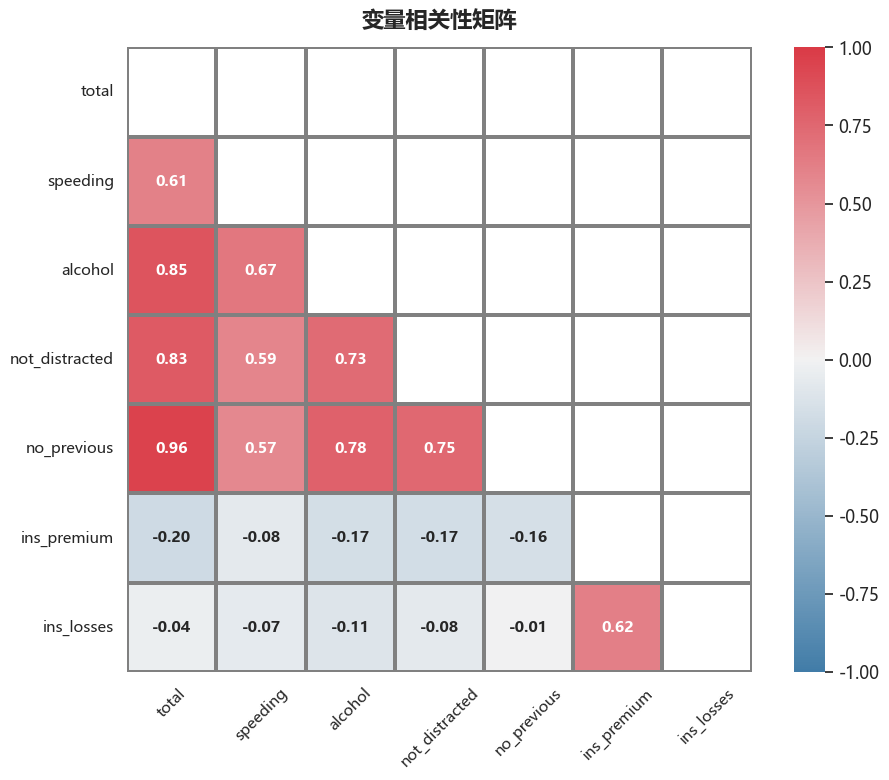

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(
    style="white", font_scale=1.1,
    rc={"font.sans-serif": ["Microsoft YaHei"],
        "font.family": "sans-serif", "axes.unicode_minus": False}
)

df = sns.load_dataset("car_crashes")
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
custom_cmap = sns.diverging_palette(240, 10, as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap=custom_cmap, center=0, square=True,
    linewidths=1.5, linecolor="gray",
    ax=ax, vmin=-1, vmax=1,
    annot_kws={"fontsize": 11, "fontweight": "bold"}
)

ax.set_title("变量相关性矩阵", fontsize=16, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=11)
ax.tick_params(axis="y", rotation=0, labelsize=11)

plt.tight_layout()
fig.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
print("✅ 图表已保存为 'correlation_heatmap.png'")
plt.show()